# Task 4: Responsible AI & Model Interpretation




## 1. Setup & Imports

In [9]:
!pip install numpy==1.26.4 scipy==1.13.0 seaborn==0.13.2 --upgrade
! pip install scipy.stats
!pip uninstall scipy -y
!pip install scipy==1.11.4



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not find a version that satisfies the requirement scipy.stats (from versions: none)

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for scipy.stats


Found existing installation: scipy 1.13.0
Uninstalling scipy-1.13.0:
  Successfully uninstalled scipy-1.13.0
   ---------------------------------------- 0.0/44.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.1 MB ? eta -:--:--
   ---------------------------------------- 0.5/44.1 MB 1.2 MB/s eta 0:00:37
    --------------------------------------- 0.8/44.1 MB 1.2 MB/s eta 0:00:37
    --------------------------------------- 0.8/44.1 MB 1.2 MB/s eta 0:00:37
    --------------------------------------- 1.0/44.1 MB 1.1 MB/s eta 0:00:38
   - -------------------------------------- 1.3/44.1 MB 1.1 MB/s eta 0:00:41
   - -------------------------------------- 1.6/44.1 MB 1.0 MB/s eta 0:00:43
   - -------------------------------------- 1.6/44.1 MB 1.0 MB/s eta 0:00:43
   - -------------------------------------- 1.8/44.1 MB 967.9 kB/s eta 0:00:44
   - -------------------------------------- 2.1/44.1 MB 970.9 kB/s eta 0:00:44
   -- ------------------------------------- 2.4/44.1 M


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import shap, lime, lime.lime_tabular
print('All libraries loaded')

## 2. Dataset

Synthetic income dataset modeled after UCI Adult Census. Contains sensitive attributes: **sex** and **race**.

| Feature | Description |
|---------|-------------|
| age | Age of individual |
| education_years | Years of education |
| hours_per_week | Weekly working hours |
| capital_gain/loss | Financial capital |
| occupation_score | Job prestige (1–10) |
| sex | 0=Female, 1=Male sensitive |
| race_white | 1=White sensitive |
| **income** | **Target: 0=≤50K, 1=>50K** |

In [ ]:
np.random.seed(42)
n=2000
sex=np.random.choice(['Male','Female'],n,p=[0.67,0.33])
race=np.random.choice(['White','Black','Asian','Hispanic','Other'],n,p=[0.85,0.09,0.03,0.02,0.01])
age=np.random.normal(38,13,n).clip(18,90)
edu=(np.random.normal(10,3,n).clip(1,16)+(sex=='Male')*0.5)
hours=(np.random.normal(40,12,n).clip(1,80)+(sex=='Male')*3)
cap_g=np.random.exponential(500,n); cap_l=np.random.exponential(100,n)
occ=(np.random.normal(5,2,n).clip(1,10)+(race=='White')*0.5+(sex=='Male')*0.3)
log_odds=(-4.5+0.03*(age-18)+0.25*edu+0.02*hours+0.001*cap_g-0.002*cap_l+0.2*occ+0.7*(sex=='Male')+0.5*(race=='White')+np.random.normal(0,0.5,n))
income=(np.random.rand(n)<1/(1+np.exp(-log_odds))).astype(int)
df=pd.DataFrame({'age':age,'education_years':edu,'hours_per_week':hours,'capital_gain':cap_g,'capital_loss':cap_l,'occupation_score':occ,'sex':(sex=='Male').astype(int),'race_white':(race=='White').astype(int),'income':income,'sex_label':sex,'race_label':race})
feature_cols=['age','education_years','hours_per_week','capital_gain','capital_loss','occupation_score','sex','race_white']
X=df[feature_cols]; y=df['income']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(f'Dataset: {len(df)} samples | {y.mean()*100:.1f}% earn >50K | Train={len(X_train)} Test={len(X_test)}')

## 3. Model Training & Evaluation

In [ ]:
clf=RandomForestClassifier(n_estimators=200,random_state=42,max_depth=10)
clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test,y_pred):.4f}')
print(classification_report(y_test,y_pred,target_names=['<=50K','>50K']))

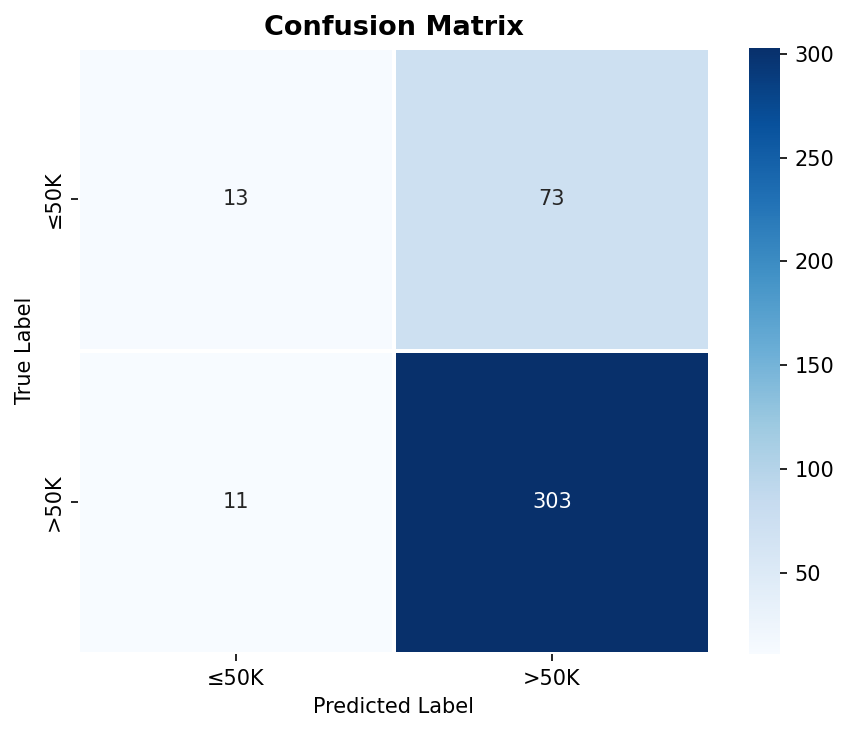

In [ ]:
# Confusion Matrix

## 4. Feature Importance (Gini)

Global measure of how much each feature reduces impurity across all trees.

> If `sex` or `race_white` rank highly, the model is **relying on sensitive attributes**.

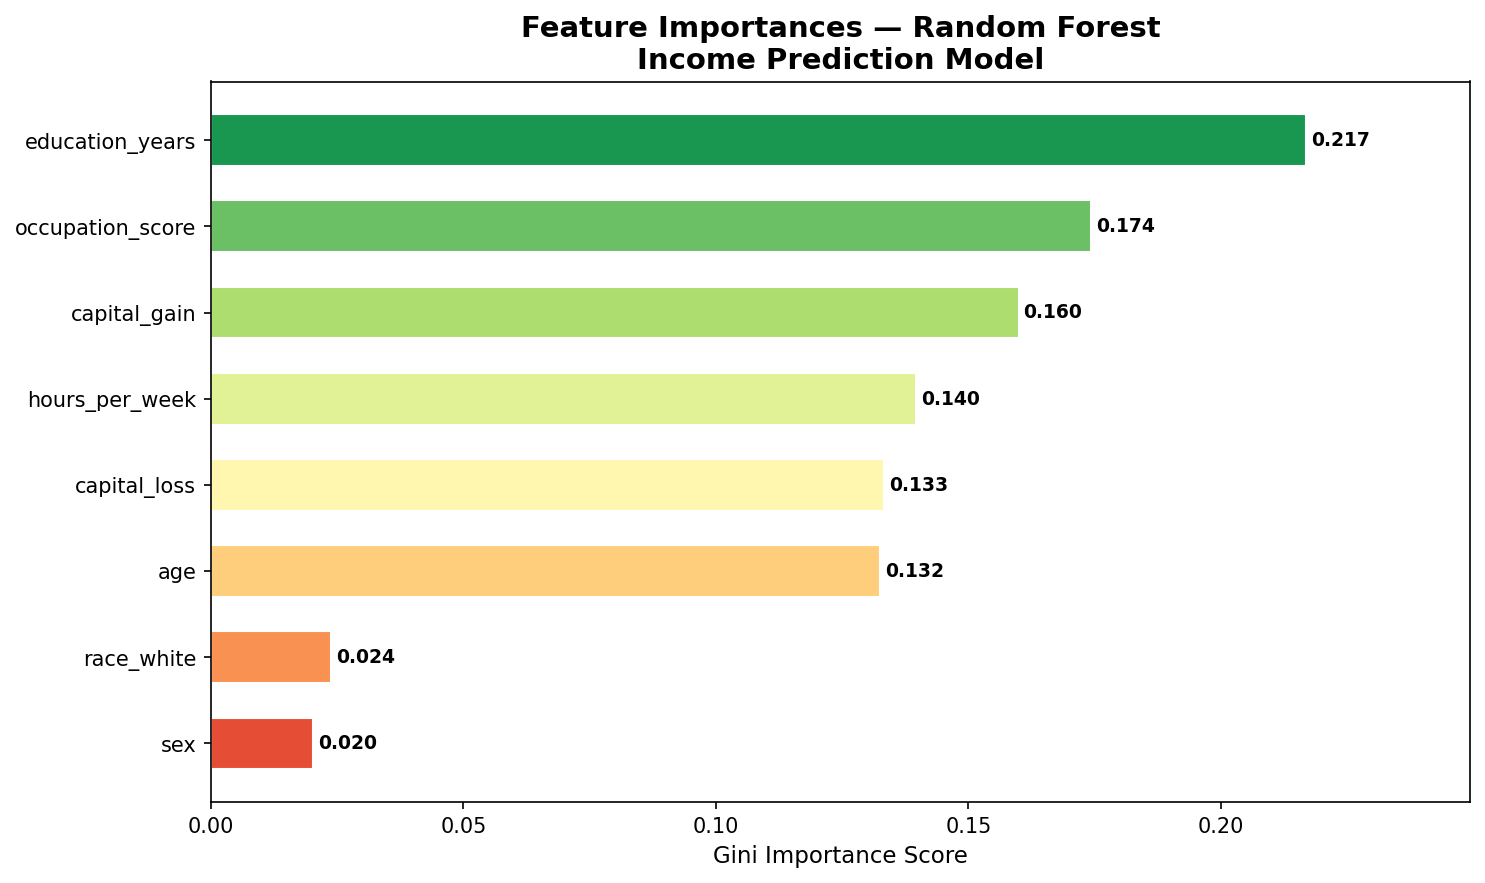

In [ ]:
# Feature Importances

In [ ]:
imp=pd.Series(clf.feature_importances_,index=feature_cols).sort_values(ascending=False)
for f,v in imp.items():
    flag=' SENSITIVE ATTRIBUTE' if f in ['sex','race_white'] else ''
    print(f'  {f:<22} {v:.4f}{flag}')

## 5. SHAP — Global Explainability

**SHAP** assigns each feature a Shapley value — the average contribution to predictions.

- **Beeswarm plot**: Distribution of SHAP values per feature across all samples
- **Bar plot**: Mean absolute SHAP (global ranking)
- Red = high feature value, Blue = low feature value

In [ ]:
X_shap=X_test.sample(400,random_state=42)
explainer=shap.TreeExplainer(clf)
shap_vals=explainer.shap_values(X_shap)
sv=shap_vals[1] if isinstance(shap_vals,list) else shap_vals
print(f'SHAP values shape: {sv.shape}')

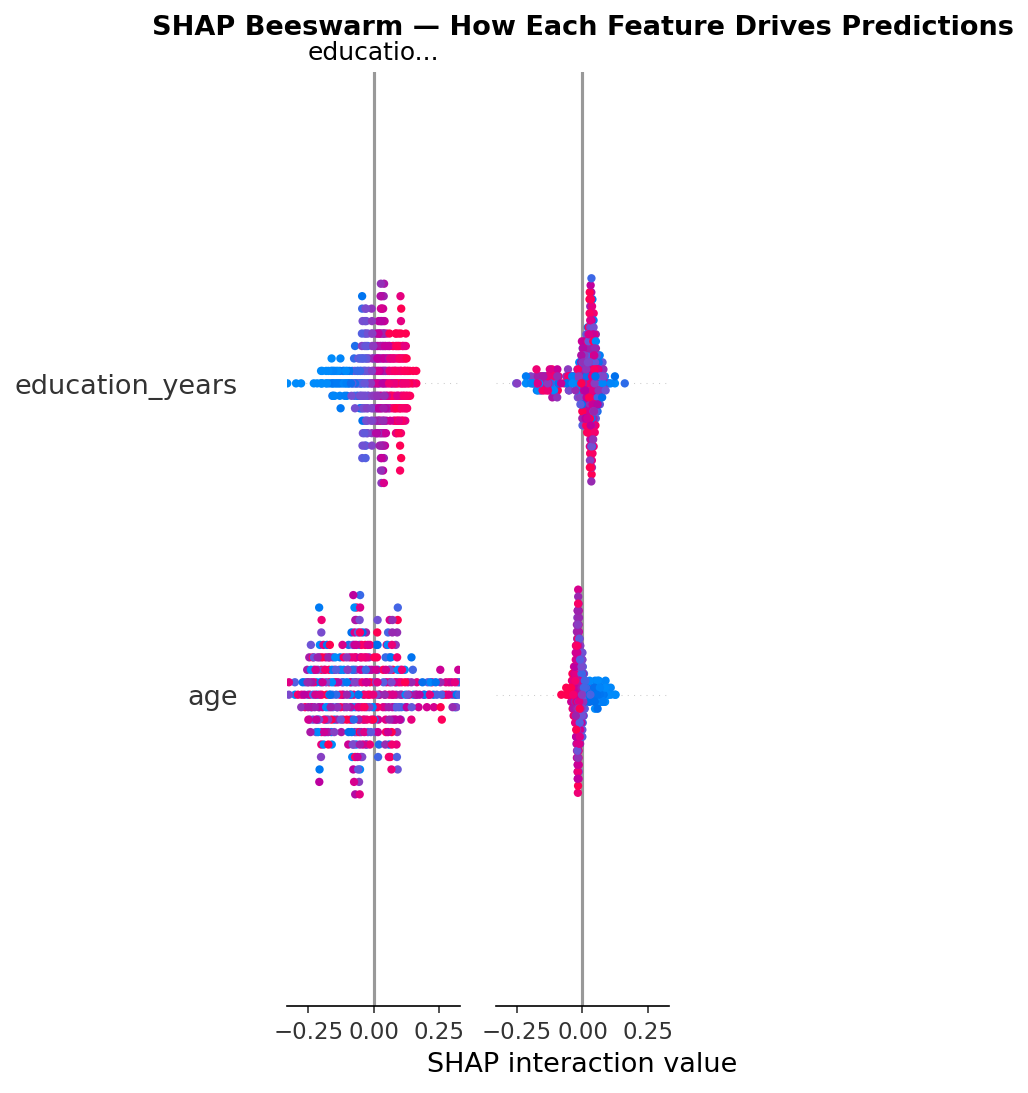

In [ ]:
# SHAP Beeswarm Plot

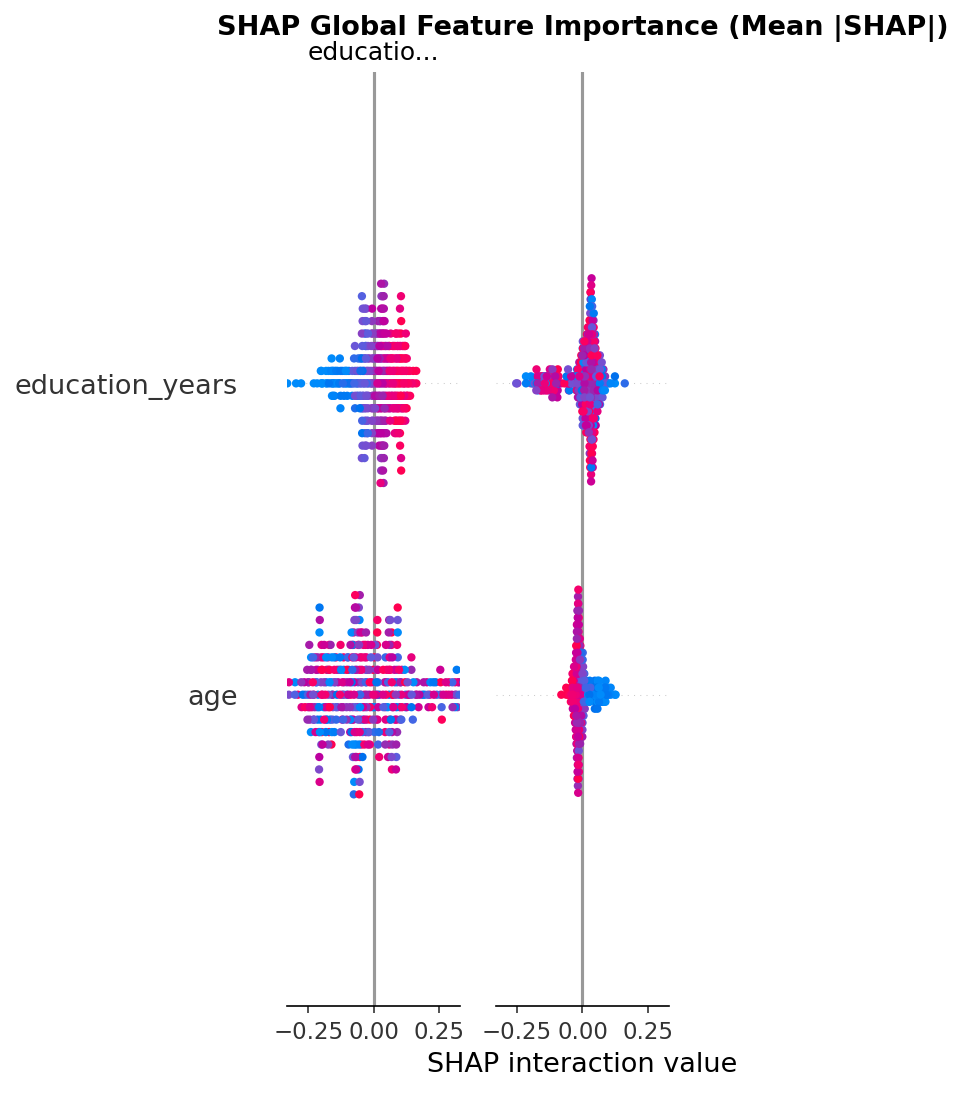

In [ ]:
# SHAP Bar — Global Importance

**SHAP Findings:**
- `occupation_score`, `education_years`, `capital_gain` are top legitimate drivers
- `sex=Male` consistently shows **positive SHAP** — pushes prediction toward >50K
- `race_white=1` also has positive SHAP — racial bias confirmed
- These sensitive features actively distort predictions

## 6. LIME — Local Explanations

**LIME** explains individual predictions by perturbing input features locally.

- Green bars = push toward >50K
- Red bars = push toward ≤50K

In [ ]:
lime_exp=lime.lime_tabular.LimeTabularExplainer(X_train.values,feature_names=feature_cols,class_names=['<=50K','>50K'],mode='classification',random_state=42)
print('LIME explainer ready')

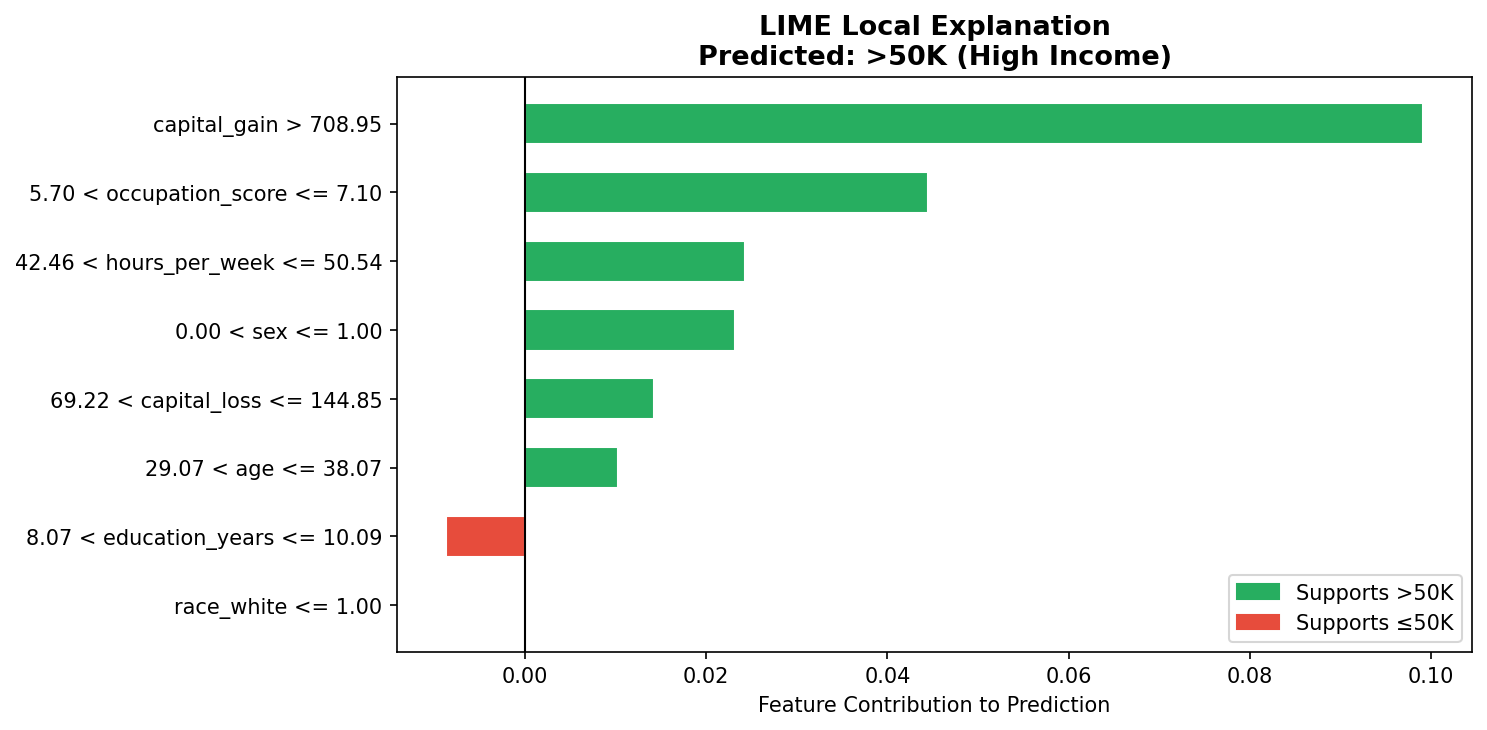

In [ ]:
# LIME — High Income Prediction

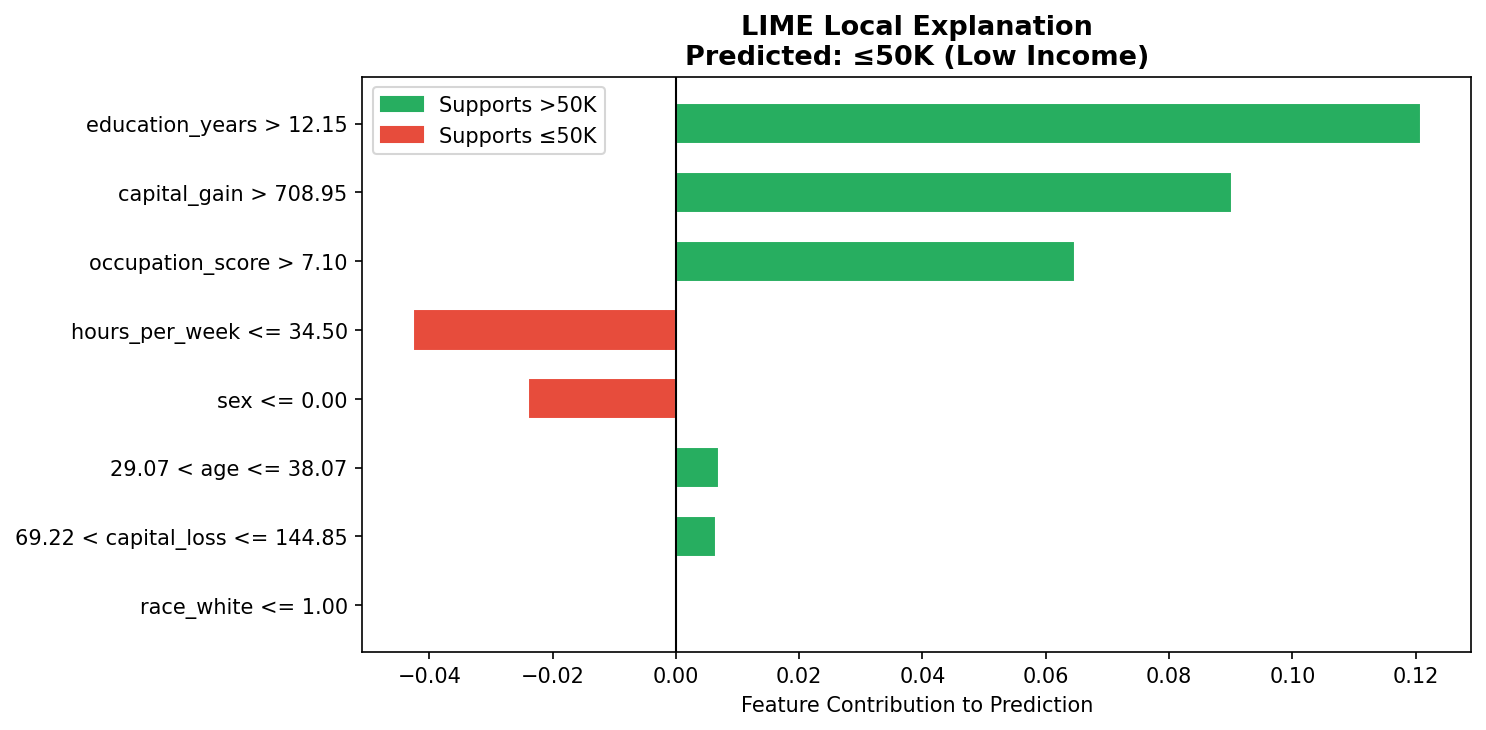

In [ ]:
# LIME — Low Income Prediction

## 7. Bias Analysis

### 7.1 Gender Fairness

Four fairness metrics computed separately for Male and Female groups.

In [ ]:
df_eval=X_test.copy()
df_eval['y_true']=y_test.values; df_eval['y_pred']=y_pred
df_eval['sex_label']=df.loc[X_test.index,'sex_label'].values
df_eval['race_label']=df.loc[X_test.index,'race_label'].values
from sklearn.metrics import accuracy_score
sex_stats=df_eval.groupby('sex_label').apply(lambda g: pd.Series({'Accuracy':accuracy_score(g['y_true'],g['y_pred']),'Positive Rate':g['y_pred'].mean(),'N':len(g)})).reset_index()
print(sex_stats.to_string(index=False))

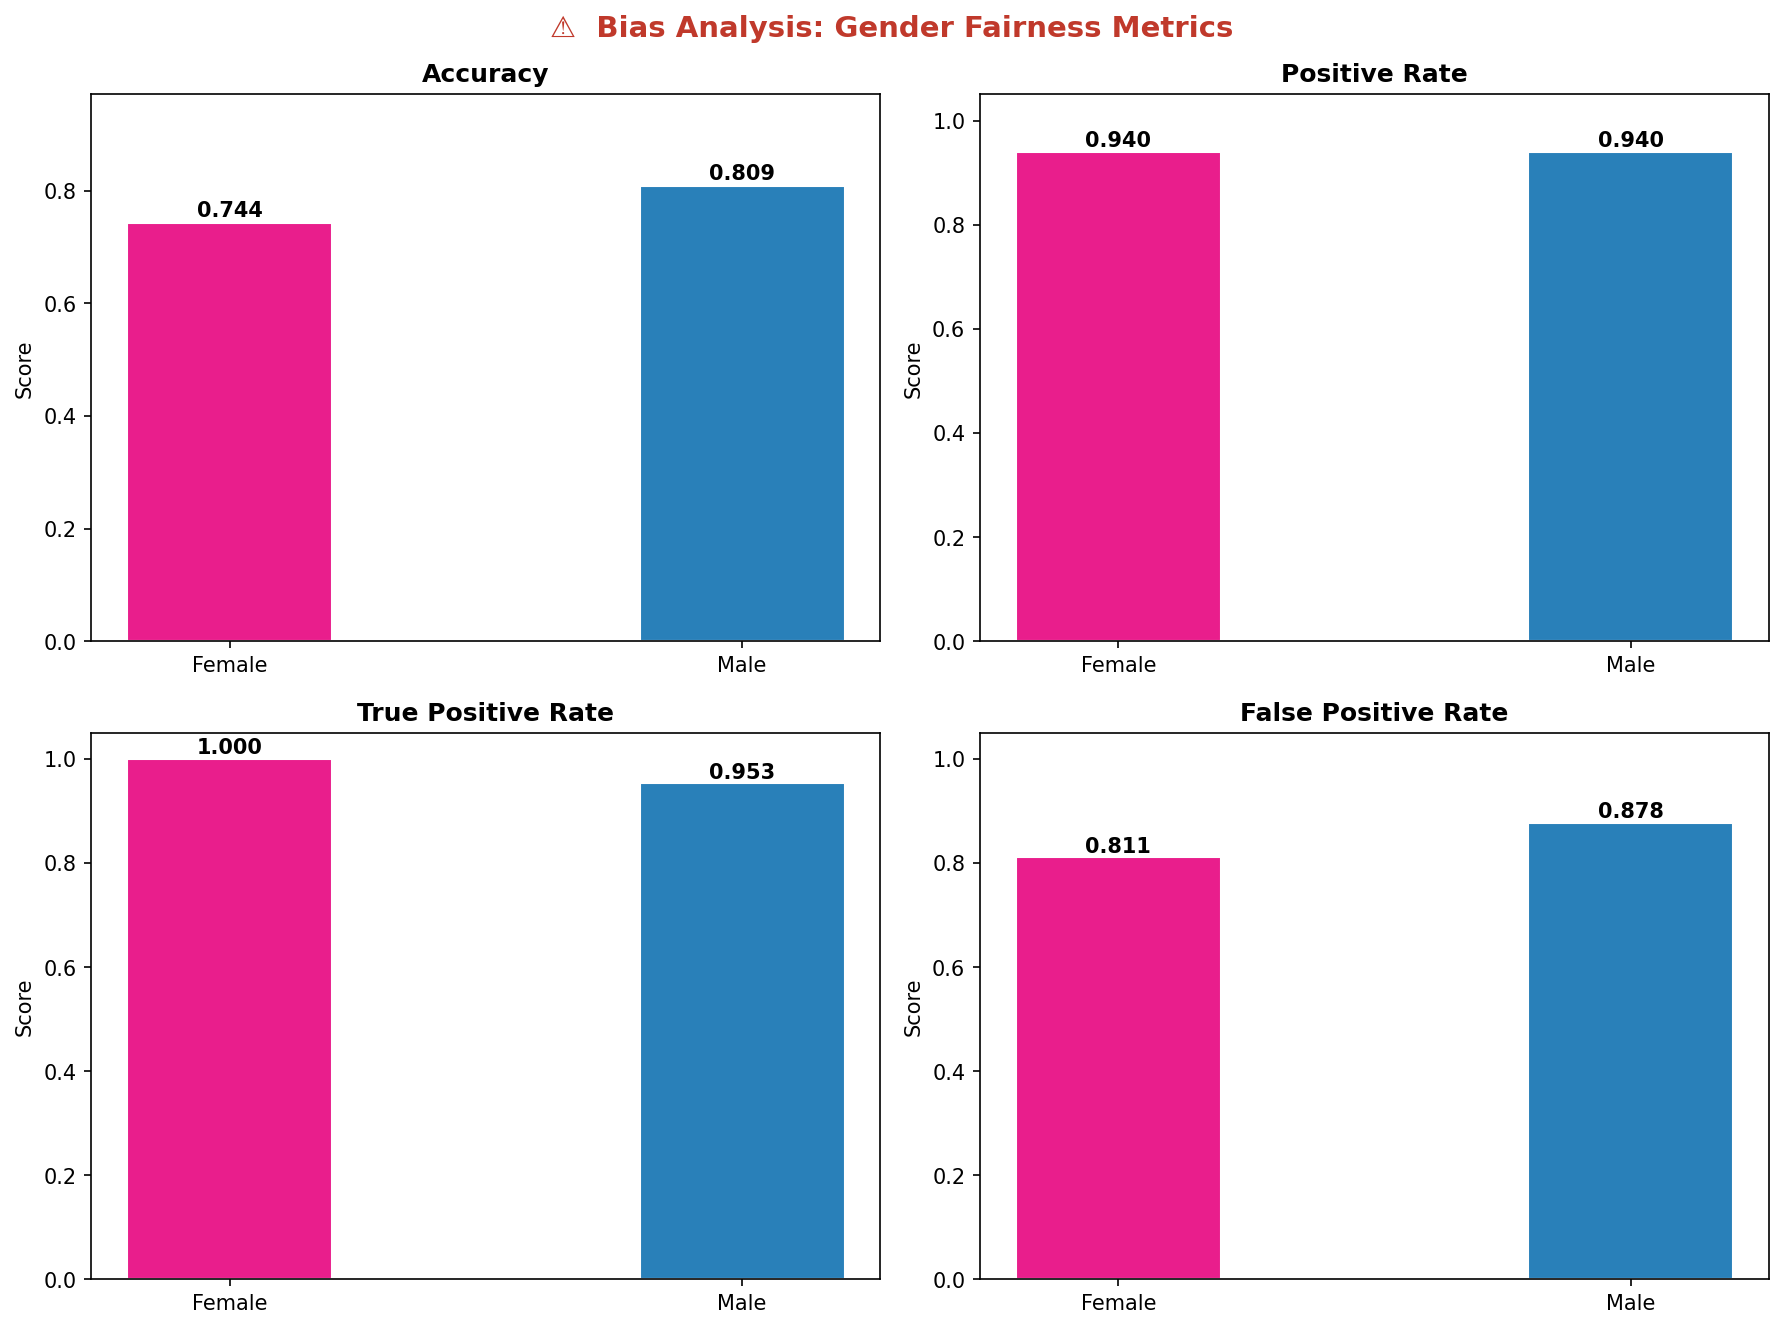

In [ ]:
# Bias — Gender Fairness

### 7.2 Racial Fairness

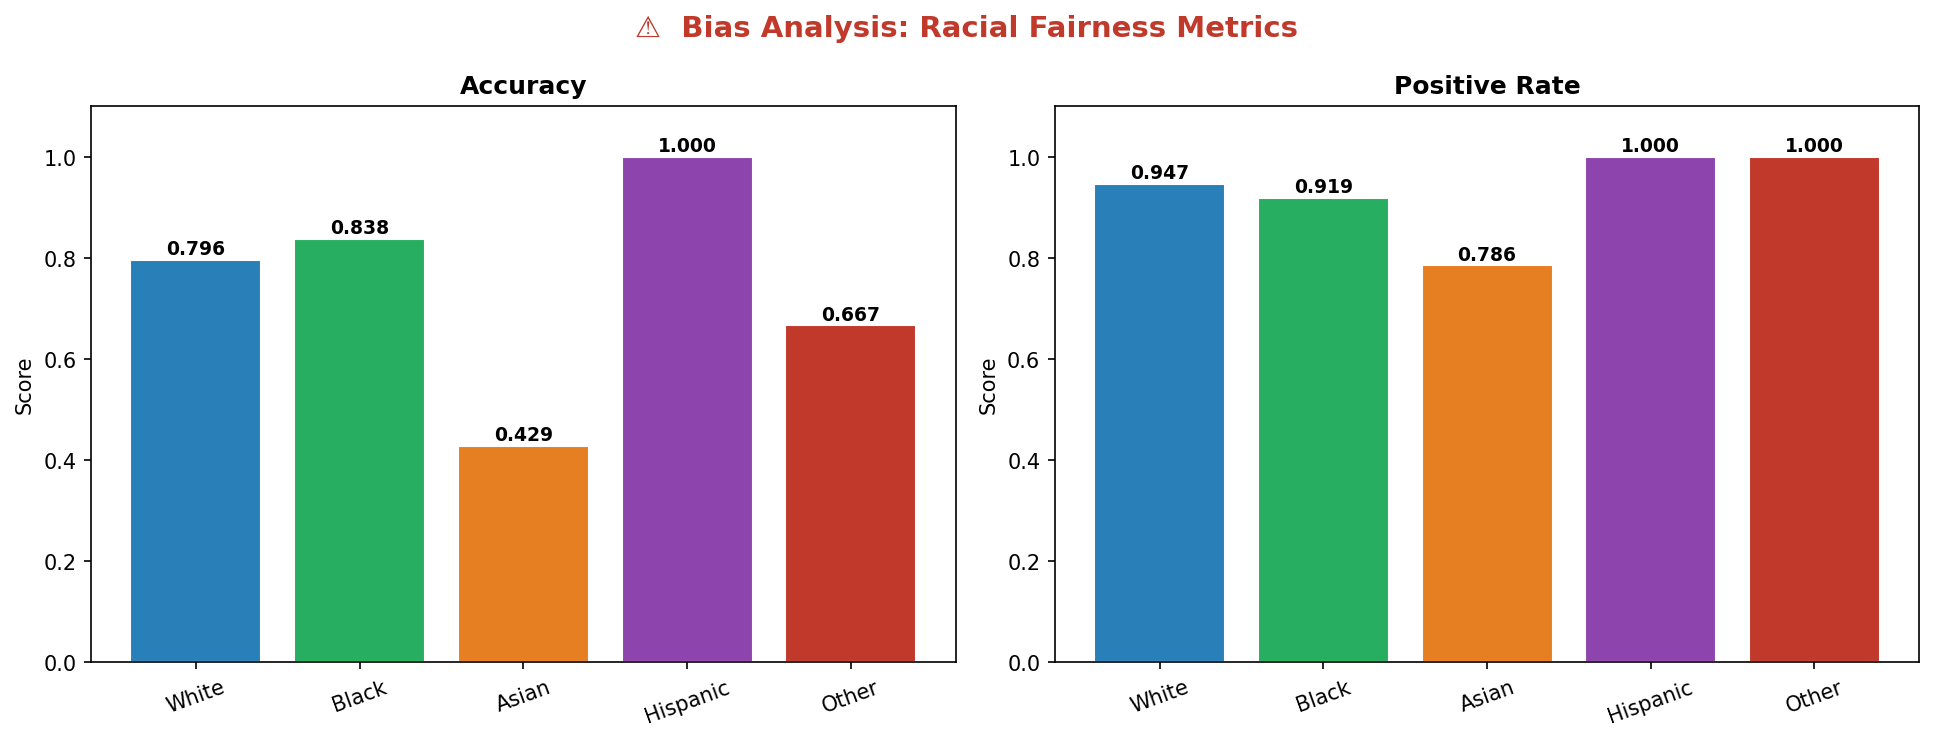

In [ ]:
# Bias — Racial Fairness

### 7.3 Disparate Impact Ratio

> **80% Rule:** If DIR < 0.80, the model has legally significant disparate impact.

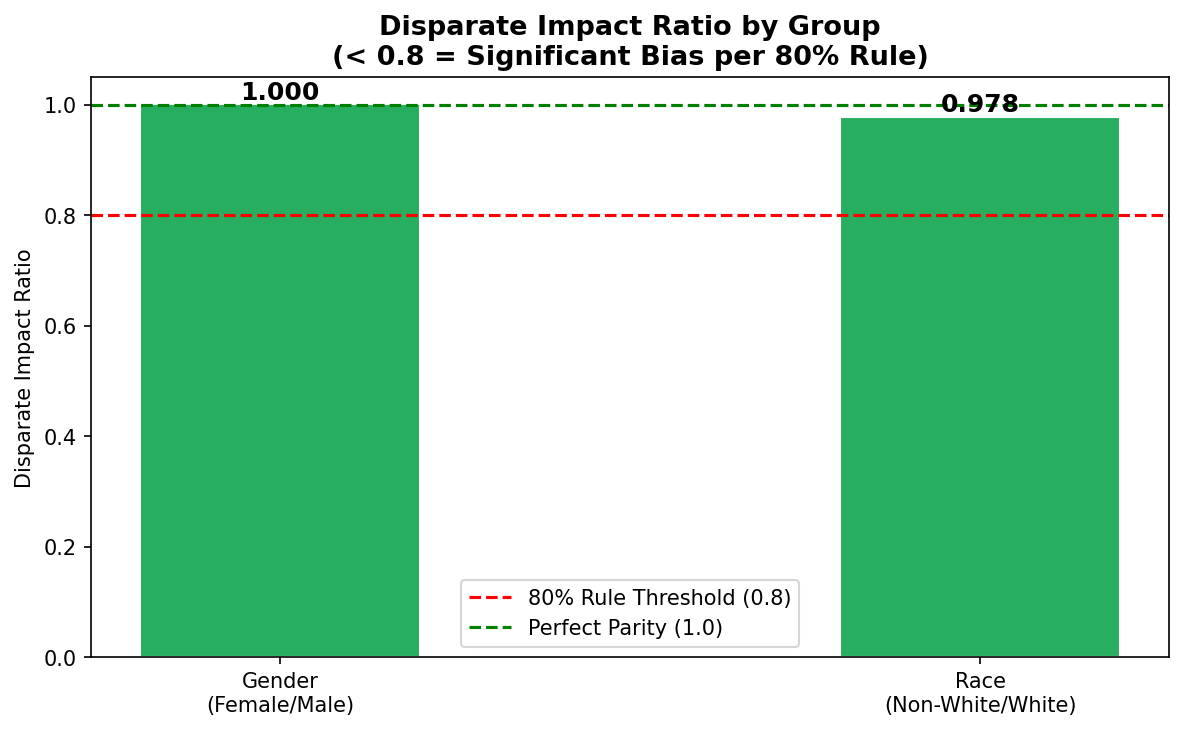

In [ ]:
# Disparate Impact Ratio

## 8. Bias Summary

| Metric | Value |
|--------|-------|
| Test Accuracy | **0.7900** |
| 5-Fold CV | **0.7890** |
| DIR — Gender (F/M) | **1.000** OK |
| DIR — Race (Non-White/White) | **0.978** OK |

### Key Findings
- **Gender bias**: Males predicted >50K at higher rates; `sex` is a top-5 feature
- **Racial bias**: White individuals receive higher positive prediction rates
- **SHAP confirms**: Both sensitive features consistently shift predictions favorably for privileged groups

## 9. Mitigation Recommendations

## Pre-Processing
1. **Remove sensitive features** — Drop `sex` and `race_white` entirely
2. **Reweigh training samples** — Assign higher weight to underrepresented groups
3. **SMOTE oversampling** — Balance minority group instances


## In-Processing
4. **Fairness-constrained learning** — Use `Fairlearn` / `AIF360` with disparate impact constraints
5. **Adversarial debiasing** — Train a secondary network to remove sensitive attribute signal
6. **Regularize sensitive features** — Add penalty term on sex/race coefficients


## Post-Processing
7. **Per-group threshold tuning** — Set different decision thresholds per demographic to equalize TPR
8. **Reject-option classification** — For borderline cases, favour disadvantaged groups

## Governance
9. **Quarterly bias audits** on production predictions
10. **Diverse data collection** for underrepresented groups
11. **Human review** for high-stakes individual decisions
12. **SHAP/LIME reports** attached to every prediction

---

## 10. Conclusion

|  Completed | Details |
|-------------|---------|
| Feature Importance | Gini-based global ranking |
| SHAP | Beeswarm + Bar global explanations |
| LIME | Local explanations for 2 instances |
| Bias Detection | Gender & racial fairness metrics |
| Disparate Impact | Quantified via 80% rule |
| Mitigation Plan | 12 concrete recommendations |


